In [1]:
import pandas as pd
import numpy as np

import seaborn as sns
from matplotlib import pyplot as plt
import matplotlib as mpl

plt.style.use('ggplot')

In [2]:
effects_df = pd.DataFrame()
transformed_data_pstrimmed = pd.DataFrame()
coefs_instances = pd.DataFrame()
for zone in ('east', 'west'):
    tmp_df = pd.read_pickle(f'../data-definitive/results/effects-{zone}.pkl')
    tmp_df['Zone'] = zone.title()
    effects_df = pd.concat([effects_df, tmp_df])

    tmp_df = pd.read_pickle(f'../data-definitive/results/transformed-subset-pstrimmed-{zone}.pkl')
    tmp_df['Zone'] = zone.title()
    transformed_data_pstrimmed = pd.concat([transformed_data_pstrimmed, tmp_df])

    tmp_df = pd.read_pickle(f'../data-definitive/results/coefs-dmllinear-instances-{zone}.pkl')
    tmp_df['Treatment'] = 'Observed'
    tmp_df = pd.concat([
        tmp_df,
        pd.read_pickle(f'../data-definitive/results/coefs-dmllinear-instances-placebo-{zone}.pkl')
    ])
    tmp_df['Treatment'] = tmp_df.Treatment.fillna('Placebo')
    tmp_df['Zone'] = zone.title()
    coefs_instances = pd.concat([coefs_instances, tmp_df])

effects_df = effects_df.reset_index().set_index(['Zone', 'index'])
transformed_data_pstrimmed = transformed_data_pstrimmed.reset_index().set_index(['Zone', 'index'])
coefs_instances = coefs_instances.reset_index().set_index(['Zone', 'Treatment', 'index'])

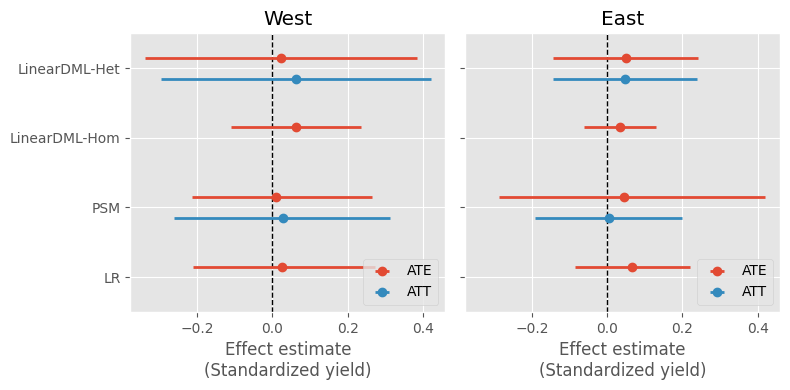

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(8, 4), sharex=True, sharey=True)

for n, zone in enumerate(('West', 'East')):
    ax = axes[n]
    tmp_df = effects_df.loc[zone].iloc[:4]
    x = tmp_df['ate']['value']
    ci = tmp_df['ate'][['ci-low', 'ci-high']]
    err = np.abs(ci.values.T - x.values)
    y = np.arange(4)
    ax.errorbar(
        y=y+.15, x=x, xerr=err,
        fmt='o', label='ATE', linewidth=2, zorder=2
    )

    x = tmp_df['att']['value']
    ci = tmp_df['att'][['ci-low', 'ci-high']]
    err = np.abs(ci.values.T - x.values)
    y = np.arange(4)
    ax.errorbar(
        y=y-.15, x=x, xerr=err,
        fmt='o', label='ATT', linewidth=2, zorder=2
    )
    ax.axvline(0, color='k', linestyle='--', linewidth=1, zorder=1)
    ax.legend(loc='lower right')
    ax.set_yticks(y)
    ax.set_yticklabels(tmp_df.index)
    ax.set_title(zone)

    ax.set_ylim(-.5, 3.5)
    ax.set_xlabel('Effect estimate\n(Standardized yield)')
plt.tight_layout()


In [5]:
coefs_names = [
    'Invest. Cap.', 'Rain', 'Soil Sand', 'Invest:Sand', 'Intercept'
]
def coefs_distplot(zone, treatment):
    tmp_df = pd.melt(coefs_instances.loc[(zone, treatment, 'point_estimate')])
    tmp_df.columns = ['Coefficient', 'Estimate']

    g = sns.FacetGrid(tmp_df, row="Coefficient", hue="Coefficient", aspect=9, height=.75, palette="viridis")
    g.map(sns.kdeplot, "Estimate", fill=True, alpha=0.7, lw=0)
    g.map(sns.kdeplot, "Estimate", color="w", lw=2)
    g.refline(x=0, color='k')
    g.fig.subplots_adjust(hspace=-.5)
    g.set_titles("")
    g.set(yticks=[], ylabel="")
    # g.set(xticks=[0])
    g.despine(bottom=True, left=True)
    # g.axes.flat[0].set_title("Common support", fontweight='bold', y=.7) 
    g.axes.flat[-1].set_xlabel('CATE coefficient estimate')
    # Optional: Add text labels for each stratum

    for ax, label in zip(g.axes.flat, coefs_names):
        ax.text(0, 0.2, label, fontweight="bold", transform=ax.transAxes)
        ax.axhline(0, color='k', linestyle="-")
        ax.set_facecolor('none')
        ax.grid(None)
        ax.tick_params(length=0)
    g.fig.suptitle(f'{zone} zone, {treatment} treatment', fontweight='bold')


/tmp/ipykernel_13281/58511698.py:5: PerformanceWarning: indexing past lexsort depth may impact performance.
  tmp_df = pd.melt(coefs_instances.loc[(zone, treatment, 'point_estimate')])


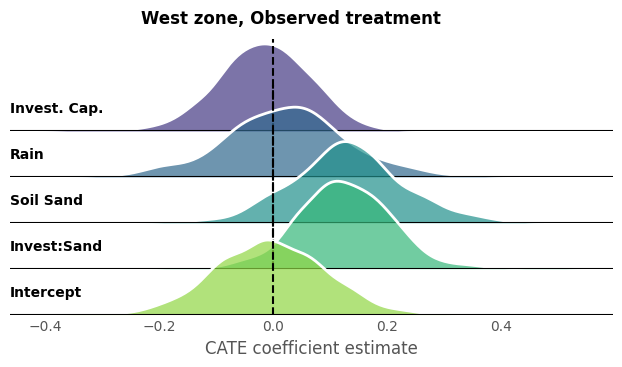

In [6]:
coefs_distplot('West', 'Observed')

/tmp/ipykernel_13281/58511698.py:5: PerformanceWarning: indexing past lexsort depth may impact performance.
  tmp_df = pd.melt(coefs_instances.loc[(zone, treatment, 'point_estimate')])


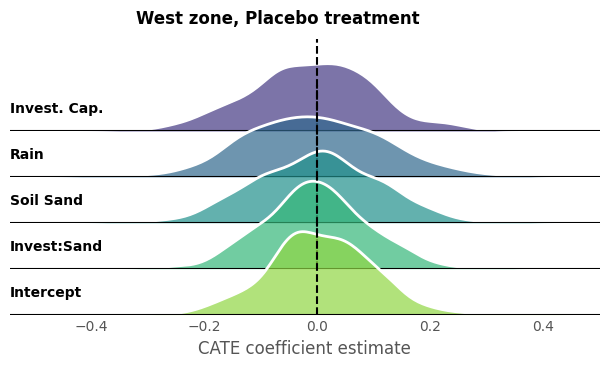

In [7]:
coefs_distplot('West', 'Placebo')

/tmp/ipykernel_13281/58511698.py:5: PerformanceWarning: indexing past lexsort depth may impact performance.
  tmp_df = pd.melt(coefs_instances.loc[(zone, treatment, 'point_estimate')])


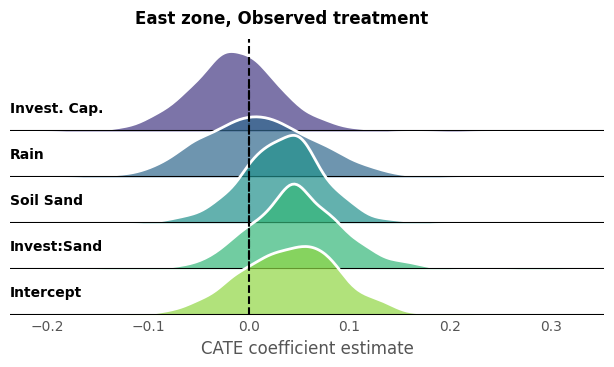

In [8]:
coefs_distplot('East', 'Observed')

/tmp/ipykernel_13281/58511698.py:5: PerformanceWarning: indexing past lexsort depth may impact performance.
  tmp_df = pd.melt(coefs_instances.loc[(zone, treatment, 'point_estimate')])


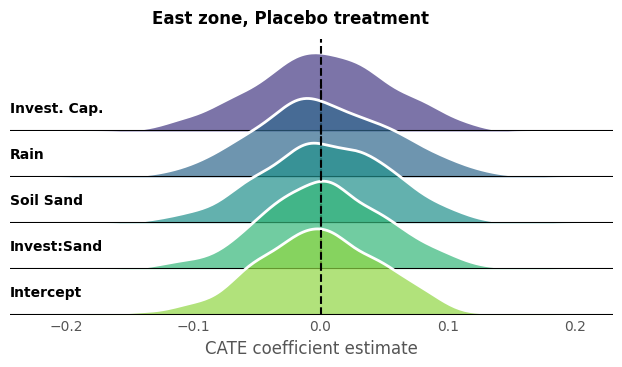

In [9]:
coefs_distplot('East', 'Placebo')

/tmp/ipykernel_13281/3859525582.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(coefs_names);


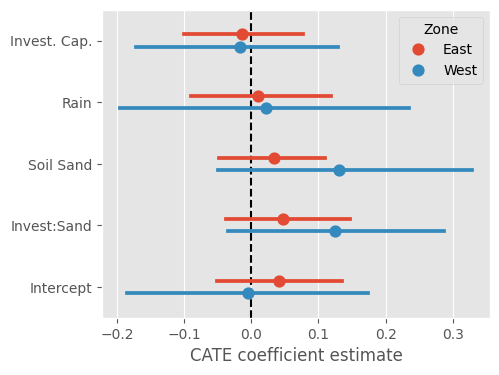

In [10]:
tmp_df = pd.melt(coefs_instances.loc[(slice(None), 'Observed', 'point_estimate')].reset_index(), id_vars='Zone')

fig, ax = plt.subplots(1, 1, figsize=(5, 4))
sns.pointplot(
    tmp_df,
    x='value', y='variable', hue='Zone',
    errorbar='pi', estimator='mean', linestyle='none',
    dodge=.2
)
ax.axvline(0, color='k', linestyle='--', zorder=1)
ax.set_xlabel('CATE coefficient estimate')
ax.set_ylabel('')
ax.set_yticklabels(coefs_names); 